In [1]:
# # ============================================================
# # IMPORTS AND REPOSITORY SETUP
# # ============================================================

# import os

# repo_url = "https://github.com/tikadatta2005/CSC60904-Deep-Learning-T3.git"
# repo_dir = "CSC60904-Deep-Learning-T3"

# if not os.path.exists(repo_dir):
#     !git clone {repo_url}

# os.chdir(repo_dir)

# !pip install -q scikit-learn seaborn matplotlib pandas

# print("Repository ready.")

In [2]:
# set the module location
import sys
import os
sys.path.append(os.path.abspath(".."))

In [3]:
# import deeplearning libraries
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

# Architecture
from modules.architectures.Architecture import Architecture

# Modules for Experimenting
from modules.helper.evaluator import evaluator
from modules.helper.calculate_metrics import calculate_metrics
from modules.helper.charts import gen_line_charts
from modules.helper.trainer import  Trainer
from modules.helper.tester import test
from modules.helper.confusion_matrix_gen import plot_confusion_matrix

# additional
from pathlib import Path

In [4]:
# Augmented DataLoaders

torch.manual_seed(41)

data_root = "../datasets/final_dataset"
batch_size = 32
img_size = 112

root = Path(data_root)

train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
])

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

# Load datasets
train_ds = datasets.ImageFolder(
    root=root / "train",
    transform=train_transform
)

val_ds = datasets.ImageFolder(
    root=root / "val",
    transform=transform
)

test_ds = datasets.ImageFolder(
    root=root / "test",
    transform=transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)

# Get class names
class_names = train_ds.classes

# Display dataset sizes
print(f"Train: {len(train_ds)}")
print(f"Validation: {len(val_ds)}")
print(f"Test: {len(test_ds)}")
print(f"Classes: {class_names}")

Train: 35100
Validation: 10800
Test: 8100
Classes: ['क', 'क्ष', 'ख', 'ग', 'घ', 'ङ', 'च', 'छ', 'ज', 'ज्ञ', 'झ', 'ञ', 'ट', 'ठ', 'ड', 'ढ', 'ण', 'त', 'त्र', 'थ', 'द', 'ध', 'न', 'प', 'फ', 'ब', 'भ', 'म', 'य', 'र', 'ल', 'व', 'श', 'ष', 'स', 'ह']


In [5]:
model = Architecture()

model.add(
    # first conv block
    nn.Conv2d(3,8,3,padding=1),
    nn.BatchNorm2d(8),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    # second conv block
    nn.Conv2d(8,16,3,padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    # third conv block
    nn.Conv2d(16,32,3,padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    # fourt conv block
    nn.Conv2d(32,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    # flatten
    nn.Flatten(),

    # fully connected neural network
    nn.Linear(64*7*7,64),

    nn.ReLU(),

    nn.Linear(64, 36)
)

Architecture(
  (layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): Batc

In [6]:
# Train and save
path = "../documentations/experiments/utsab-aug-lr2e-3-m0-9"

# Using Trainer to train the model
trainer = Trainer(
    model,
    train_loader,
    val_loader,
    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=2e-3,
        momentum=0.9,
        weight_decay=3e-5,
    ),
    device="cuda",
    criterion = nn.CrossEntropyLoss()
)

# this is metrucs
metrics = trainer.fit(30, path, 1);

EPOCH 5 completed | Training Loss = 0.0827379832222528 | Validation Loss = 0.04818467252928406
EPOCH 10 completed | Training Loss = 0.03194349097520319 | Validation Loss = 0.020394760632570008
EPOCH 15 completed | Training Loss = 0.018792906407245208 | Validation Loss = 0.009225302882855323
EPOCH 20 completed | Training Loss = 0.011288053425912489 | Validation Loss = 0.004592529132954569
EPOCH 25 completed | Training Loss = 0.0078562746814464 | Validation Loss = 0.003801738970501382
EPOCH 30 completed | Training Loss = 0.00828463031603191 | Validation Loss = 0.003622175927379156


In [7]:
def find_best_models(df):
    best = df[df["val_accuracy"] == df["val_accuracy"].max()] # combines and remove duplicates
    return best

In [8]:
find_best_models(metrics)

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
22,23,0.009434,0.002525,0.997265,0.997266,0.997265,0.997265,0.999259,0.999261,0.999259,0.999259


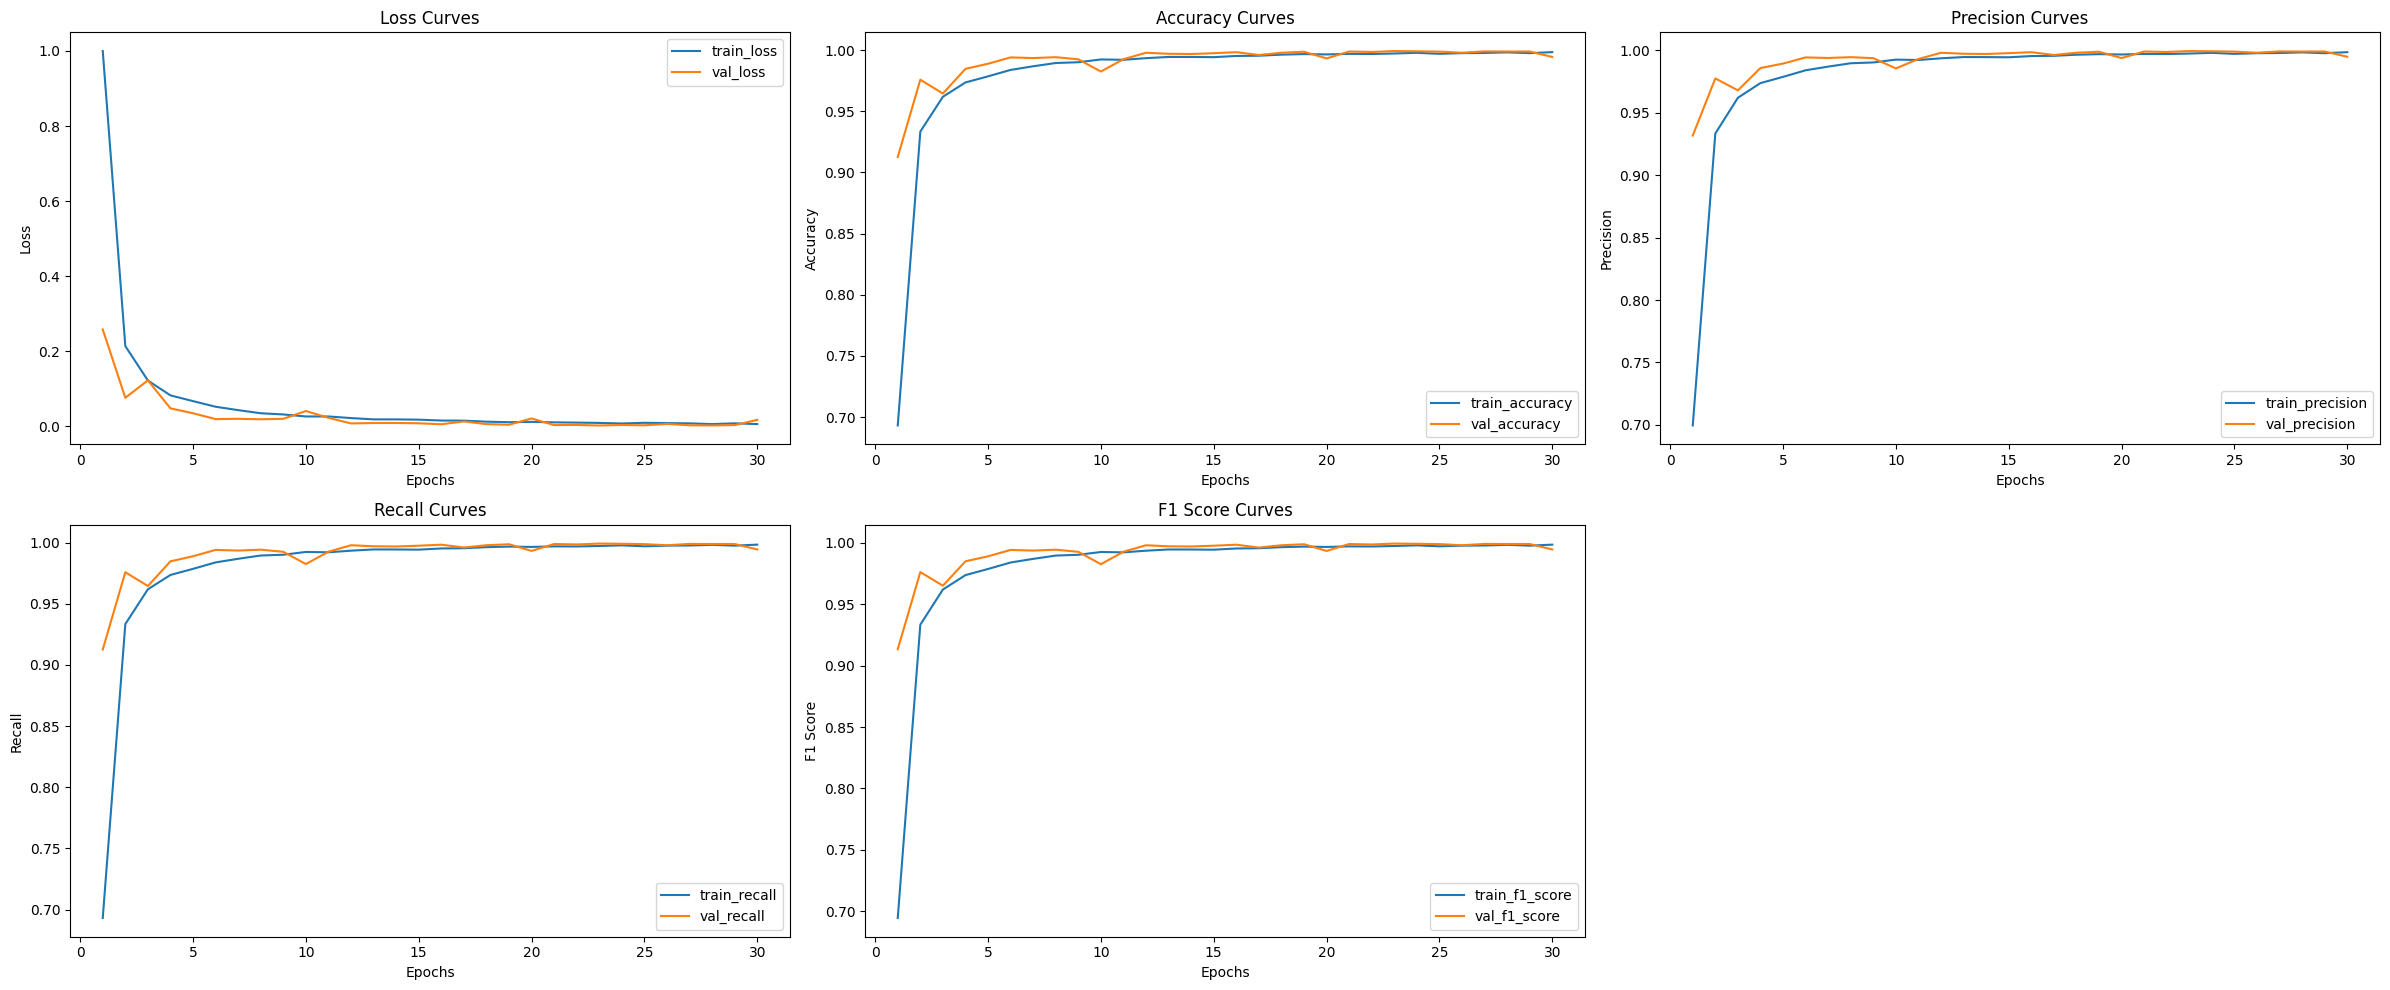

In [9]:
gen_line_charts(metrics, path, "training_metrics_graph.png", ["train_", "val_"])